In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Load the dataset
df = pd.read_excel("/content/Amazon_Customer_Purchase_Data.xlsx")

# Show first 5 rows
df.head()


Data Cleaning.

In [30]:
df_clean = df.copy()

# Fill numeric
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Rating'].fillna(df_clean['Rating'].median(), inplace=True)
df_clean['Customer_Lifetime_Value'].fillna(df_clean['Customer_Lifetime_Value'].median(), inplace=True)

# Category-wise mean for Purchase Amount
df_clean['Purchase_Amount'] = df_clean.groupby('Product_Category')['Purchase_Amount']\
.transform(lambda x: x.fillna(x.mean()))

# Fill categorical
df_clean['Customer_Name'].fillna(df_clean['Customer_Name'].mode()[0], inplace=True)
df_clean['Feedback_Comments'].fillna(df_clean['Feedback_Comments'].mode()[0], inplace=True)

# Remove duplicates
df_clean = df_clean.drop_duplicates(subset=['Customer_ID', 'Purchase_Date'])

# Standardize Gender
df_clean['Gender'] = df_clean['Gender'].str.capitalize()

# Outlier handling (IQR)
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

df_clean['Purchase_Amount'] = cap_outliers_iqr(df_clean['Purchase_Amount'])
df_clean['Customer_Lifetime_Value'] = cap_outliers_iqr(df_clean['Customer_Lifetime_Value'])

df_clean.isnull().sum()

/tmp/ipython-input-1896212337.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
/tmp/ipython-input-1896212337.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
Location,0
Product_Category,0
Product_ID,0
Purchase_Date,0
Purchase_Amount,0
Payment_Method,0


Feature Engineering

In [31]:
customer_metrics = df_clean.groupby('Customer_ID').agg(
    Total_Spend=('Purchase_Amount','sum'),
    Order_Count=('Purchase_Amount','count'),
    Avg_Rating=('Rating','mean')
).reset_index()

scaler = MinMaxScaler()
customer_metrics[['Spend_Scaled','Orders_Scaled']] = scaler.fit_transform(
    customer_metrics[['Total_Spend','Order_Count']]
)

customer_metrics['Loyalty_Score_New'] = (
    0.6 * customer_metrics['Spend_Scaled'] +
    0.4 * customer_metrics['Orders_Scaled']
) * 100

def segment_customer(score):
    if score < 33:
        return 'New'
    elif score < 66:
        return 'Regular'
    else:
        return 'VIP'

customer_metrics['Customer_Segment_New'] = customer_metrics['Loyalty_Score_New'].apply(segment_customer)

df_fe = df_clean.merge(
    customer_metrics[['Customer_ID','Total_Spend','Order_Count','Loyalty_Score_New','Customer_Segment_New']],
    on='Customer_ID',
    how='left'
)

df_fe['Discount_Applied_Flag'] = df_fe['Discount_Applied'].map({'Yes':1,'No':0})
df_fe['Return_Status_Flag'] = df_fe['Return_Status'].map({'Yes':1,'No':0})

df_fe.head()

,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,...,Discount_Applied,Return_Status,Customer_Segment,Preferred_Shopping_Channel,Total_Spend,Order_Count,Loyalty_Score_New,Customer_Segment_New,Discount_Applied_Flag,Return_Status_Flag
0,17270,John,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,...,No,No,Regular,In-store,491.643012,1,23.929090,New,0,0
1,10860,Eve,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,...,Yes,Yes,New,In-store,144.326722,1,6.670879,New,1,1
2,15390,John,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,...,No,No,VIP,Online,308.303081,2,28.152228,New,0,0
3,15191,Eve,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,226.655516,Bank Transfer,...,Yes,Yes,Regular,Online,226.655516,1,10.761812,New,1,1
4,15734,Eve,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,37.851880,Bank Transfer,...,No,Yes,Regular,Both,37.851880,1,1.380124,New,0,1


K-Means Clustering

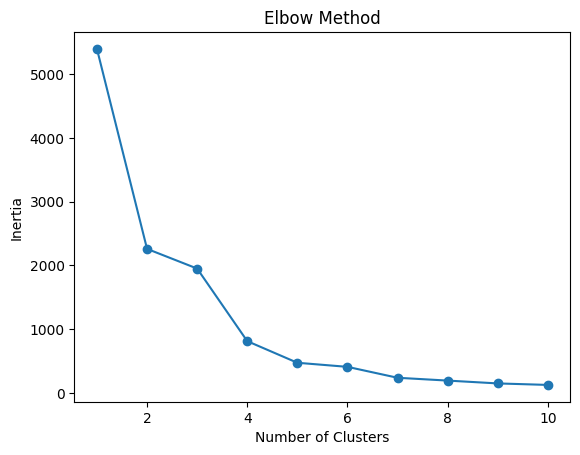

         Total_Spend  Order_Count  Loyalty_Score_New
Cluster                                             
0         766.464470     3.045455          64.857746
1         352.882592     1.000000          17.034059
2         517.394495     2.000000          38.542019
3         122.161521     1.001502           5.589506


,Customer_ID,Customer_Name,Age,Gender,Location,Product_Category,Product_ID,Purchase_Date,Purchase_Amount,Payment_Method,...,Return_Status,Customer_Segment,Preferred_Shopping_Channel,Total_Spend,Order_Count,Loyalty_Score_New,Customer_Segment_New,Discount_Applied_Flag,Return_Status_Flag,Cluster
0,17270,John,56.0,Other,New York,Books,674,2020-01-01 00:00:00,491.643012,Cash,...,No,Regular,In-store,491.643012,1,23.929090,New,0,0,1
1,10860,Eve,33.0,Other,Houston,Home Appliances,393,2020-01-01 01:00:00,144.326722,Cash,...,Yes,New,In-store,144.326722,1,6.670879,New,1,1,3
2,15390,John,50.0,Female,Houston,Clothing,995,2020-01-01 02:00:00,109.301892,Bank Transfer,...,No,VIP,Online,308.303081,2,28.152228,New,0,0,2
3,15191,Eve,66.0,Other,San Francisco,Electronics,405,2020-01-01 03:00:00,226.655516,Bank Transfer,...,Yes,Regular,Online,226.655516,1,10.761812,New,1,1,3
4,15734,Eve,38.0,Female,New York,Toys,353,2020-01-01 04:00:00,37.851880,Bank Transfer,...,Yes,Regular,Both,37.851880,1,1.380124,New,0,1,3


In [37]:
cluster_data = customer_metrics[['Total_Spend','Order_Count','Loyalty_Score_New']]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42)
customer_metrics['Cluster'] = kmeans.fit_predict(cluster_scaled)

print(customer_metrics.groupby('Cluster')[['Total_Spend','Order_Count','Loyalty_Score_New']].mean())

df_kmeans = df_fe.merge(
    customer_metrics[['Customer_ID','Cluster']],
    on='Customer_ID',
    how='left'
)

df_kmeans.head()

### K-Means Customer Segmentation Results

- **Cluster 0 (High-Value Customers):**  
  Customers with highest total spending, more orders, and high loyalty scores. These customers are ideal for VIP offers and premium marketing strategies.

- **Cluster 2 (Mid-Value Customers):**  
  Moderate spenders with regular purchases. These customers can be targeted with personalized discounts to increase their lifetime value.

- **Cluster 1 (Low-Mid Value Customers):**  
  Customers with lower spending and fewer purchases. Promotional campaigns can encourage repeat purchases.

- **Cluster 3 (Low-Value Customers):**  
  Customers with minimal spending and low loyalty. Retention strategies and onboarding campaigns are recommended for this group.



Linear Regression for CLV Prediction

In [33]:
model_data = df_kmeans[['Age','Total_Spend','Order_Count','Discount_Applied_Flag',
                         'Loyalty_Score_New','Customer_Lifetime_Value','Payment_Method']]

model_data = pd.get_dummies(model_data, columns=['Payment_Method'], drop_first=True)

X = model_data.drop('Customer_Lifetime_Value', axis=1)
y = model_data['Customer_Lifetime_Value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("RMSE:", rmse)

R2 Score: 0.6345849844132068
RMSE: 858.2014036000008


### CLV Prediction Model (Linear Regression)

The Linear Regression model was trained to predict Customer Lifetime Value (CLV) using:
- Age
- Total spend
- Order count
- Discount usage
- Loyalty score
- Payment method

**Model Performance:**
- R² Score: 0.63  
- RMSE: 858

This indicates that the model explains a significant portion of the variation in customer lifetime value and can be used for revenue forecasting and identifying high-value customers.
